# Temas Tratados en el Trabajo Práctico 6

* Modelado de problemas en espacios de estado.

* Algoritmos de planificación hacia adelante y hacia atrás.

* Representación y solución de problemas descritos en lenguaje STRIPS.

* Algoritmo GRAPHPLAN.

* Planificación con restricciones de tiempo y recursos.

* Caminos críticos y tiempos de relajación.

## Ejercicios Teóricos

1. ¿En qué tipo de algoritmos se basa un planificador para encontrar el mejor camino a un estado solución?

### Resolución

Un planificador se basa en **algoritmos de búsqueda en espacios de estados**. El problema de planificación se representa mediante:

- un **estado inicial**;
- un conjunto de **acciones** que permiten pasar de un estado a otro;
- un **objetivo** que debe cumplirse;
- un costo asociado al plan.

Cada estado constituye un nodo del espacio de búsqueda y cada acción aplicable representa una transición:

$$
s_0 \xrightarrow{a_1} s_1 \xrightarrow{a_2} \cdots
\xrightarrow{a_n} s_n
$$

El planificador debe encontrar una secuencia de acciones:

$$
\pi=\langle a_1,a_2,\ldots,a_n\rangle
$$

tal que el estado final $s_n$ satisfaga el objetivo $g$:

$$
g\subseteq s_n
$$

La búsqueda puede realizarse en dos direcciones:

- **Hacia adelante o por progresión:** comienza en el estado inicial y aplica sucesivamente las acciones habilitadas hasta encontrar un estado que satisfaga el objetivo.
- **Hacia atrás o por regresión:** comienza en el objetivo y busca qué acciones podrían alcanzarlo, reemplazando progresivamente los objetivos por las precondiciones de esas acciones hasta llegar al estado inicial.

Para explorar el espacio pueden utilizarse algoritmos de búsqueda **no informada**, como búsqueda en anchura o costo uniforme, o algoritmos de búsqueda **informada**, como A*, que emplean una función heurística para priorizar los estados más prometedores:

$$
f(n)=g(n)+h(n)
$$

donde:

- $g(n)$ es el costo acumulado desde el estado inicial;
- $h(n)$ es una estimación del costo restante hasta el objetivo.

Si todas las acciones tienen costo unitario, el costo de un plan coincide con su cantidad de acciones:

$$
Costo(\pi)=|\pi|
$$

Por lo tanto, encontrar el mejor camino significa encontrar un plan válido de costo mínimo. En el caso de costo unitario, esto equivale a encontrar el plan que alcance el objetivo utilizando la menor cantidad de acciones.


2. ¿Qué tres elementos se encuentran dentro de una acción formulada en lenguaje STRIPS? Describa brevemente qué función cumple cada uno.

### Resolución

En STRIPS, una acción se identifica mediante un **nombre** y, cuando corresponde, una lista de parámetros. Su comportamiento se describe mediante tres componentes principales:

#### 1. Precondiciones

Las precondiciones indican qué hechos deben ser verdaderos antes de ejecutar la acción. Una acción $a$ puede aplicarse en un estado $s$ solamente cuando todas sus precondiciones se encuentran satisfechas:

$$
Precond(a)\subseteq s
$$

#### 2. Lista de agregados

La lista $Add(a)$ contiene los hechos que pasan a ser verdaderos después de ejecutar la acción.

#### 3. Lista de eliminados

La lista $Del(a)$ contiene los hechos que dejan de ser verdaderos como consecuencia de la acción.

El nuevo estado se calcula conservando los hechos que no cambian, eliminando los indicados por $Del(a)$ y agregando los indicados por $Add(a)$:

$$
s'=(s\setminus Del(a))\cup Add(a)
$$

Por ejemplo, la acción de tomar una pieza puede representarse como:

$$
Acción(Tomar(P1))
$$

$$
Precond=
\{
En(P1,Mesa),\ PinzaLibre
\}
$$

$$
Add=
\{
Sujeta(P1)
\}
$$

$$
Del=
\{
En(P1,Mesa),\ PinzaLibre
\}
$$

Si el estado inicial es:

$$
s=
\{
En(P1,Mesa),\ PinzaLibre,\ SoporteLibre
\}
$$

al aplicar la acción se obtiene:

$$
s'=
\{
Sujeta(P1),\ SoporteLibre
\}
$$

El hecho $SoporteLibre$ permanece verdadero porque la acción no lo incluye en su lista de eliminados. De esta manera, STRIPS modifica únicamente los hechos indicados explícitamente en los efectos de la acción.

3. Describa las ventajas y desventajas de desarrollar un algoritmo de planificación hacia adelante y hacia atrás en el espacio de estados.


### Resolución

Los problemas de planificación pueden resolverse mediante búsqueda hacia adelante, denominada **progresión**, o mediante búsqueda hacia atrás, denominada **regresión**. Ambas estrategias buscan una secuencia de acciones válida, pero recorren el problema en sentidos opuestos.

#### Planificación hacia adelante o por progresión

La progresión comienza en el estado inicial $s_0$. En cada estado identifica las acciones cuyas precondiciones se cumplen y genera los estados sucesores:

$$
s'=(s\setminus Del(a))\cup Add(a)
$$

La búsqueda finaliza cuando encuentra un estado que satisface el objetivo:

$$
g\subseteq s
$$

Su principal ventaja es que resulta sencilla de implementar, porque en cada estado se conoce directamente qué acciones son aplicables y cómo calcular sus sucesores. Además, puede utilizar algoritmos de búsqueda conocidos, como búsqueda en anchura, costo uniforme o A*.

Su principal desventaja es que puede presentar un factor de ramificación elevado. El planificador considera todas las acciones aplicables, incluso aquellas que no contribuyen al objetivo. Esto puede producir una gran cantidad de estados alternativos y repetidos, provocando una explosión del espacio de búsqueda.

Por ejemplo, desde un estado inicial podrían generarse varias ramas:

$$
s_0
\begin{cases}
\xrightarrow{a_1}s_1^1\\
\xrightarrow{a_2}s_1^2\\
\xrightarrow{a_3}s_1^3
\end{cases}
$$

aunque solo una de ellas resulte útil para alcanzar la meta.

#### Planificación hacia atrás o por regresión

La regresión comienza con el conjunto de objetivos $G$ y busca acciones cuyos efectos permitan alcanzarlos.

Una acción $a$ es **relevante** si consigue al menos uno de los objetivos:

$$
Add(a)\cap G\neq\varnothing
$$

Además, debe ser **consistente**, es decir, no debe eliminar otro objetivo que también se necesite:

$$
Del(a)\cap G=\varnothing
$$

Una vez seleccionada una acción, los objetivos que esta consigue se reemplazan por sus precondiciones:

$$
Regresar(G,a)=
(G\setminus Add(a))\cup Precond(a)
$$

La búsqueda continúa hasta que el estado inicial satisface todos los subobjetivos regresados.

Su principal ventaja es que considera solamente acciones relacionadas con el objetivo, evitando muchas acciones irrelevantes y reduciendo en algunos problemas la cantidad de ramas exploradas.

Su desventaja es que resulta más difícil de implementar. No siempre es evidente cuáles son los estados predecesores de un objetivo, y se deben manipular conjuntos de subobjetivos parcialmente especificados. También es necesario controlar que las acciones elegidas no eliminen otros hechos deseados y decidir entre varias acciones cuando un mismo objetivo puede alcanzarse de diferentes maneras.

En síntesis:

| Característica | Progresión | Regresión |
|---|---|---|
| Punto de partida | Estado inicial | Objetivo |
| Dirección | $s_0\rightarrow g$ | $g\rightarrow s_0$ |
| Selección de acciones | Acciones aplicables | Acciones relevantes y consistentes |
| Elementos explorados | Estados completos | Conjuntos de subobjetivos |
| Ventaja principal | Implementación más directa | Evita muchas acciones irrelevantes |
| Desventaja principal | Alto factor de ramificación | Generación de predecesores más compleja |

Por lo tanto, la progresión pregunta:

> ¿Qué acciones puedo ejecutar desde el estado actual?

Mientras que la regresión pregunta:

> ¿Qué acción debería ejecutarse antes para alcanzar el objetivo actual?

4. Considere el problema de ponerse uno mismo zapatos y medias. Aplique GRAPHPLAN a este problema y muestre la solución obtenida. Muestre el plan de orden parcial que es solución e indique cuántas linealizaciones diferentes existen para el plan de orden parcial.

### Resolución

GRAPHPLAN representa el problema mediante un **grafo de planificación** formado por niveles alternados de estados y acciones:

$$
S_0 \longrightarrow A_0 \longrightarrow S_1
\longrightarrow A_1 \longrightarrow S_2
$$

donde:

- $S_i$ contiene los literales que pueden alcanzarse en el nivel $i$.
- $A_i$ contiene las acciones aplicables a partir de los literales de $S_i$.
- Los enlaces de exclusión mutua o **mutex** indican qué acciones o literales no pueden coexistir.

Los niveles de estado representan distintas posibilidades. Por eso, la aparición de varios literales en un mismo nivel no significa automáticamente que todos puedan cumplirse simultáneamente: también debe comprobarse que no sean mutex.

---

## 1. Definición formal del problema

Se consideran los lados:

$$
x\in\{Der,Izq\}
$$

y los siguientes predicados:

- $MediaPuesta(x)$: la media del lado $x$ está puesta.
- $ZapatoPuesto(x)$: el zapato del lado $x$ está puesto.

### Estado inicial

Inicialmente no hay medias ni zapatos puestos:

$$
S_0=\varnothing
$$

Por la hipótesis de mundo cerrado, los hechos que no aparecen en el estado se consideran falsos.

### Objetivo

El objetivo es tener puestos ambos zapatos:

$$
G=
\{
ZapatoPuesto(Der),
ZapatoPuesto(Izq)
\}
$$

Equivalentemente:

$$
G=
ZapatoPuesto(Der)\land ZapatoPuesto(Izq)
$$

No es necesario incluir las medias en el objetivo, porque serán condiciones necesarias para ponerse los zapatos y permanecerán puestas después de hacerlo.

---

## 2. Acciones en STRIPS

### Poner la media derecha

$$
Acción(PonerMedia(Der))
$$

$$
Precond=\varnothing
$$

$$
Add=
\{
MediaPuesta(Der)
\}
$$

$$
Del=\varnothing
$$

### Poner la media izquierda

$$
Acción(PonerMedia(Izq))
$$

$$
Precond=\varnothing
$$

$$
Add=
\{
MediaPuesta(Izq)
\}
$$

$$
Del=\varnothing
$$

### Poner el zapato derecho

$$
Acción(PonerZapato(Der))
$$

$$
Precond=
\{
MediaPuesta(Der)
\}
$$

$$
Add=
\{
ZapatoPuesto(Der)
\}
$$

$$
Del=\varnothing
$$

### Poner el zapato izquierdo

$$
Acción(PonerZapato(Izq))
$$

$$
Precond=
\{
MediaPuesta(Izq)
\}
$$

$$
Add=
\{
ZapatoPuesto(Izq)
\}
$$

Ninguna acción elimina hechos, porque ponerse un zapato no provoca que la media deje de estar puesta.

---

# 3. Construcción del grafo de planificación

## Nivel inicial $S_0$

El nivel inicial es:

$$
S_0=\varnothing
$$

Las acciones para ponerse las medias no tienen precondiciones, por lo que ambas son aplicables.

---

## Nivel de acciones $A_0$

$$
A_0=
\{
PonerMedia(Der),
PonerMedia(Izq)
\}
$$

Estas acciones no son mutex porque:

- no tienen efectos inconsistentes;
- ninguna elimina una precondición o un efecto de la otra;
- no poseen precondiciones que entren en competencia.

Por lo tanto, pueden ejecutarse en paralelo o en cualquier orden:

$$
PonerMedia(Der)\parallel PonerMedia(Izq)
$$

---

## Nivel de estados $S_1$

Los efectos de las acciones de $A_0$ generan:

$$
S_1=
\{
MediaPuesta(Der),
MediaPuesta(Izq)
\}
$$

Estos dos literales no son mutex, porque fueron producidos por acciones compatibles.

El objetivo todavía no está presente, ya que aún no aparecen:

$$
ZapatoPuesto(Der)
\qquad\text{y}\qquad
ZapatoPuesto(Izq)
$$

Por eso debe expandirse el grafo.

---

## Acciones de persistencia o no-op

GRAPHPLAN incorpora acciones de persistencia para conservar los hechos verdaderos entre niveles.

Para cualquier literal $p$, una acción de persistencia se representa como:

$$
Acción(NoOp(p))
$$

$$
Precond=\{p\}
$$

$$
Add=\{p\}
$$

$$
Del=\varnothing
$$

En este problema aparecen:

$$
NoOp(MediaPuesta(Der))
$$

$$
NoOp(MediaPuesta(Izq))
$$

Estas acciones indican que las medias pueden permanecer puestas mientras se realizan otras acciones.

---

## Nivel de acciones $A_1$

A partir de $S_1$ pueden aplicarse las acciones:

$$
A_1=
\{
PonerZapato(Der),
PonerZapato(Izq),
NoOp(MediaPuesta(Der)),
NoOp(MediaPuesta(Izq))
\}
$$

Las acciones `PonerMedia(Der)` y `PonerMedia(Izq)` también seguirían siendo aplicables porque no poseen precondiciones, pero repetirlas no agrega información nueva y no resulta necesario para obtener el plan mínimo.

Las acciones:

$$
PonerZapato(Der)
\qquad\text{y}\qquad
PonerZapato(Izq)
$$

no son mutex porque:

- sus precondiciones no son mutex;
- no poseen efectos contradictorios;
- ninguna elimina una precondición o efecto de la otra.

Por lo tanto, también pueden ejecutarse en paralelo:

$$
PonerZapato(Der)\parallel PonerZapato(Izq)
$$

---

## Nivel de estados $S_2$

Los efectos de $A_1$ permiten obtener:

$$
S_2=
\{
MediaPuesta(Der),
MediaPuesta(Izq),
ZapatoPuesto(Der),
ZapatoPuesto(Izq)
\}
$$

Los dos literales del objetivo aparecen en $S_2$:

$$
G\subseteq S_2
$$

Además:

$$
\neg Mutex
\left(
ZapatoPuesto(Der),
ZapatoPuesto(Izq)
\right)
$$

Por lo tanto, GRAPHPLAN puede intentar extraer una solución.

---

# 4. Extracción del plan hacia atrás

La extracción comienza en $S_2$ con los objetivos:

$$
\{
ZapatoPuesto(Der),
ZapatoPuesto(Izq)
\}
$$

Para producirlos se seleccionan en $A_1$:

$$
\{
PonerZapato(Der),
PonerZapato(Izq)
\}
$$

Sus precondiciones son:

$$
\{
MediaPuesta(Der),
MediaPuesta(Izq)
\}
$$

Para producir estas precondiciones se seleccionan en $A_0$:

$$
\{
PonerMedia(Der),
PonerMedia(Izq)
\}
$$

Se alcanza así el estado inicial, ya que las acciones para ponerse las medias no tienen precondiciones.

El plan paralelo obtenido por GRAPHPLAN es:

$$
\boxed{
\begin{aligned}
A_0:\;&PonerMedia(Der)\parallel PonerMedia(Izq)\\
A_1:\;&PonerZapato(Der)\parallel PonerZapato(Izq)
\end{aligned}
}
$$

---

# 5. Plan de Orden Parcial

El conjunto de acciones reales es:

$$
A=
\{
PonerMedia(Der),
PonerMedia(Izq),
PonerZapato(Der),
PonerZapato(Izq)
\}
$$

Las únicas restricciones de precedencia necesarias son:

$$
PonerMedia(Der)\prec PonerZapato(Der)
$$

$$
PonerMedia(Izq)\prec PonerZapato(Izq)
$$

No existe una restricción entre las acciones correspondientes a pies diferentes.

Utilizando las acciones auxiliares `Inicio` y `Fin`, el plan puede expresarse como:

$$
Inicio
\prec
PonerMedia(Der)
\prec
PonerZapato(Der)
\prec
Fin
$$

$$
Inicio
\prec
PonerMedia(Izq)
\prec
PonerZapato(Izq)
\prec
Fin
$$

Los enlaces causales principales son:

$$
PonerMedia(Der)
\xrightarrow{MediaPuesta(Der)}
PonerZapato(Der)
$$

$$
PonerMedia(Izq)
\xrightarrow{MediaPuesta(Izq)}
PonerZapato(Izq)
$$

Por lo tanto, el plan está formado por dos cadenas independientes de dos acciones cada una.

---

# 6. Linealizaciones del plan parcial

Una linealización es una secuencia totalmente ordenada que respeta todas las restricciones del plan parcial.

Tenemos dos cadenas:

$$
D=
\left[
PonerMedia(Der),
PonerZapato(Der)
\right]
$$

$$
I=
\left[
PonerMedia(Izq),
PonerZapato(Izq)
\right]
$$

Debemos intercalar ambas cadenas sin modificar el orden interno de ninguna.

La cantidad de formas de elegir cuáles dos de las cuatro posiciones serán ocupadas por las acciones del pie derecho es:

$$
\binom{4}{2}
=
\frac{4!}{2!\,2!}
=
6
$$

Por lo tanto:

$$
\boxed{\text{Existen 6 linealizaciones válidas}}
$$

Las seis linealizaciones son:

1. 
$$
PonerMedia(Der)
\rightarrow
PonerZapato(Der)
\rightarrow
PonerMedia(Izq)
\rightarrow
PonerZapato(Izq)
$$

2. 
$$
PonerMedia(Der)
\rightarrow
PonerMedia(Izq)
\rightarrow
PonerZapato(Der)
\rightarrow
PonerZapato(Izq)
$$

3. 
$$
PonerMedia(Der)
\rightarrow
PonerMedia(Izq)
\rightarrow
PonerZapato(Izq)
\rightarrow
PonerZapato(Der)
$$

4. 
$$
PonerMedia(Izq)
\rightarrow
PonerZapato(Izq)
\rightarrow
PonerMedia(Der)
\rightarrow
PonerZapato(Der)
$$

5. 
$$
PonerMedia(Izq)
\rightarrow
PonerMedia(Der)
\rightarrow
PonerZapato(Izq)
\rightarrow
PonerZapato(Der)
$$

6. 
$$
PonerMedia(Izq)
\rightarrow
PonerMedia(Der)
\rightarrow
PonerZapato(Der)
\rightarrow
PonerZapato(Izq)
$$

Todas estas secuencias son válidas porque respetan las dos únicas dependencias obligatorias:

$$
PonerMedia(Der)\prec PonerZapato(Der)
$$

$$
PonerMedia(Izq)\prec PonerZapato(Izq)
$$

In [1]:
%pip install networkx matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Cantidad de linealizaciones válidas: 6

1. PonerMedia(Der) -> PonerMedia(Izq) -> PonerZapato(Der) -> PonerZapato(Izq)
2. PonerMedia(Der) -> PonerMedia(Izq) -> PonerZapato(Izq) -> PonerZapato(Der)
3. PonerMedia(Der) -> PonerZapato(Der) -> PonerMedia(Izq) -> PonerZapato(Izq)
4. PonerMedia(Izq) -> PonerMedia(Der) -> PonerZapato(Der) -> PonerZapato(Izq)
5. PonerMedia(Izq) -> PonerMedia(Der) -> PonerZapato(Izq) -> PonerZapato(Der)
6. PonerMedia(Izq) -> PonerZapato(Izq) -> PonerMedia(Der) -> PonerZapato(Der)


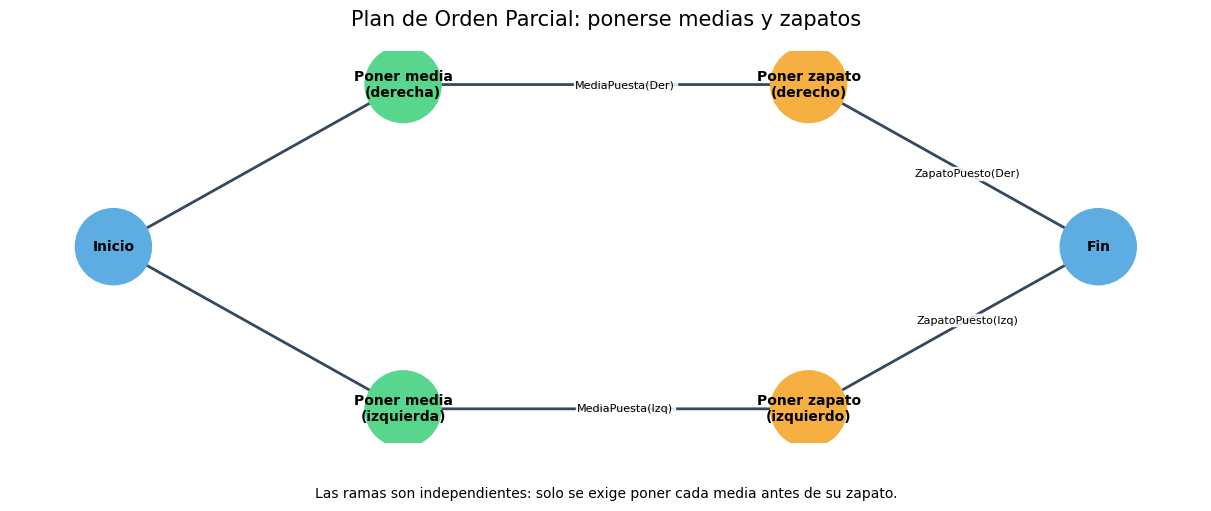

In [2]:
import networkx as nx
import matplotlib.pyplot as plt


# ============================================================
# 1. CÁLCULO DE LAS LINEALIZACIONES
# ============================================================

# Grafo que contiene únicamente las cuatro acciones reales.
grafo_acciones = nx.DiGraph()

acciones = [
    "PonerMedia(Der)",
    "PonerMedia(Izq)",
    "PonerZapato(Der)",
    "PonerZapato(Izq)",
]

grafo_acciones.add_nodes_from(acciones)

# Restricciones obligatorias del plan parcial.
grafo_acciones.add_edges_from(
    [
        ("PonerMedia(Der)", "PonerZapato(Der)"),
        ("PonerMedia(Izq)", "PonerZapato(Izq)"),
    ]
)

# Cada ordenamiento topológico es una linealización válida.
linealizaciones = list(
    nx.all_topological_sorts(grafo_acciones)
)

# Ordenamos el resultado para obtener una salida reproducible.
prioridad = {
    accion: indice
    for indice, accion in enumerate(acciones)
}

linealizaciones.sort(
    key=lambda secuencia: tuple(
        prioridad[accion] for accion in secuencia
    )
)

print(
    f"Cantidad de linealizaciones válidas: "
    f"{len(linealizaciones)}\n"
)

for numero, secuencia in enumerate(
    linealizaciones,
    start=1
):
    print(
        f"{numero}. {' -> '.join(secuencia)}"
    )


# ============================================================
# 2. GRÁFICO DEL PLAN DE ORDEN PARCIAL
# ============================================================

plan = nx.DiGraph()

# Se agregan Inicio y Fin como acciones auxiliares del POP.
plan.add_edges_from(
    [
        ("Inicio", "PonerMedia(Der)"),
        ("Inicio", "PonerMedia(Izq)"),
        ("PonerMedia(Der)", "PonerZapato(Der)"),
        ("PonerMedia(Izq)", "PonerZapato(Izq)"),
        ("PonerZapato(Der)", "Fin"),
        ("PonerZapato(Izq)", "Fin"),
    ]
)

# Posiciones manuales para mostrar las dos ramas independientes.
posiciones = {
    "Inicio": (0, 0),
    "PonerMedia(Der)": (1, 1),
    "PonerMedia(Izq)": (1, -1),
    "PonerZapato(Der)": (2.4, 1),
    "PonerZapato(Izq)": (2.4, -1),
    "Fin": (3.4, 0),
}

# Etiquetas más cortas para que el gráfico sea legible.
etiquetas_nodos = {
    "Inicio": "Inicio",
    "Fin": "Fin",
    "PonerMedia(Der)": "Poner media\n(derecha)",
    "PonerMedia(Izq)": "Poner media\n(izquierda)",
    "PonerZapato(Der)": "Poner zapato\n(derecho)",
    "PonerZapato(Izq)": "Poner zapato\n(izquierdo)",
}

colores = {
    "Inicio": "#5DADE2",
    "Fin": "#5DADE2",
    "PonerMedia(Der)": "#58D68D",
    "PonerMedia(Izq)": "#58D68D",
    "PonerZapato(Der)": "#F5B041",
    "PonerZapato(Izq)": "#F5B041",
}

fig, ax = plt.subplots(
    figsize=(12, 5),
    constrained_layout=True
)

# Nodos.
nx.draw_networkx_nodes(
    plan,
    pos=posiciones,
    node_color=[
        colores[nodo] for nodo in plan.nodes
    ],
    node_size=3000,
    ax=ax,
)

# Nombres de las acciones.
nx.draw_networkx_labels(
    plan,
    pos=posiciones,
    labels=etiquetas_nodos,
    font_size=10,
    font_weight="bold",
    ax=ax,
)

# Flechas de precedencia.
nx.draw_networkx_edges(
    plan,
    pos=posiciones,
    edge_color="#34495E",
    width=2,
    arrows=True,
    arrowsize=22,
    ax=ax,
)

# Condiciones protegidas por los enlaces causales.
enlaces_causales = {
    (
        "PonerMedia(Der)",
        "PonerZapato(Der)",
    ): "MediaPuesta(Der)",
    (
        "PonerMedia(Izq)",
        "PonerZapato(Izq)",
    ): "MediaPuesta(Izq)",
    (
        "PonerZapato(Der)",
        "Fin",
    ): "ZapatoPuesto(Der)",
    (
        "PonerZapato(Izq)",
        "Fin",
    ): "ZapatoPuesto(Izq)",
}

nx.draw_networkx_edge_labels(
    plan,
    pos=posiciones,
    edge_labels=enlaces_causales,
    font_size=8,
    rotate=False,
    label_pos=0.55,
    bbox={
        "alpha": 0.85,
        "color": "white",
        "pad": 1,
    },
    ax=ax,
)

ax.set_title(
    "Plan de Orden Parcial: ponerse medias y zapatos",
    fontsize=15,
    pad=18,
)

ax.text(
    1.7,
    -1.55,
    "Las ramas son independientes: "
    "solo se exige poner cada media antes de su zapato.",
    ha="center",
    fontsize=10,
)

ax.set_axis_off()
plt.show()

5. Se requiere ensamblar una máquina cuyas piezas están identificadas con las letras A, B, C, D y E. El tiempo que se tarda en ensamblar cada pieza es:

* A: 2 semanas

* B: 1 semana

* C: 4 semanas

* D: 3 semanas

* E: 5 semanas

    El orden de ensamblaje de cada pieza requiere que:

* A esté realizado antes que C

* B esté realizado antes que C

* B esté realizado antes que D

* C esté realizado antes que E

* D esté realizado antes que E

    Con esta información:

        5.1 Arme el Plan de Orden Parcial.

        5.2 Encuentre el Camino Crítico.

        5.3 Encuentre los tiempos de relajación.

        5.4 Dibuje un diagrama temporal indicando las tareas y los tiempos de relajación encontrados.

### 5.1 Plan de Orden Parcial

Un **Plan de Orden Parcial**, o POP, establece únicamente las relaciones de precedencia necesarias entre las tareas. Dos tareas que no están relacionadas por una restricción pueden ejecutarse simultáneamente, siempre que existan recursos suficientes.

Las tareas y sus duraciones son:

| Tarea | Duración |
|---|---:|
| $A$ | 2 semanas |
| $B$ | 1 semana |
| $C$ | 4 semanas |
| $D$ | 3 semanas |
| $E$ | 5 semanas |

El conjunto de tareas se completa con dos eventos virtuales de duración nula:

- $Start$: representa el comienzo del proyecto.
- $Finish$: representa la finalización del proyecto.

Por lo tanto:

$$
T=\{Start,A,B,C,D,E,Finish\}
$$

Las restricciones dadas por el problema son:

$$
A\prec C
$$

$$
B\prec C
$$

$$
B\prec D
$$

$$
C\prec E
$$

$$
D\prec E
$$

Las tareas $A$ y $B$ no tienen predecesoras, por lo que pueden comenzar después de $Start$:

$$
Start\prec A
$$

$$
Start\prec B
$$

La tarea $E$ es la última actividad real del proyecto:

$$
E\prec Finish
$$

El conjunto completo de restricciones de orden queda:

$$
O=
\{
Start\prec A,\;
Start\prec B,\;
A\prec C,\;
B\prec C,\;
B\prec D,\;
C\prec E,\;
D\prec E,\;
E\prec Finish
\}
$$

El plan puede representarse mediante las siguientes ramas:

$$
Start\rightarrow A\rightarrow C\rightarrow E\rightarrow Finish
$$

$$
Start\rightarrow B\rightarrow C\rightarrow E\rightarrow Finish
$$

$$
Start\rightarrow B\rightarrow D\rightarrow E\rightarrow Finish
$$

Las tareas $A$ y $B$ pueden ejecutarse inicialmente en paralelo. Sin embargo, $C$ solamente puede comenzar cuando hayan finalizado tanto $A$ como $B$. De forma semejante, $E$ debe esperar a que finalicen $C$ y $D$.

### 5.2 Camino crítico

Para encontrar el camino crítico se calculan primero los tiempos más tempranos mediante un recorrido hacia adelante.

Para cada tarea se definen:

- $IT$: inicio temprano, es decir, el primer momento en que puede comenzar.
- $FT$: fin temprano, es decir, el primer momento en que puede terminar.

Las ecuaciones utilizadas son:

$$
IT_i=
\max_{j\in Pred(i)}
\left(FT_j\right)
$$

$$
FT_i=IT_i+d_i
$$

donde $Pred(i)$ representa el conjunto de tareas predecesoras de $i$ y $d_i$ es su duración.

Si una tarea no posee predecesoras, puede comenzar en el instante cero.

---

#### Tareas A y B

Como $A$ y $B$ no tienen predecesoras:

$$
IT_A=0
\qquad
FT_A=IT_A+d_A=0+2=2
$$

$$
IT_B=0
\qquad
FT_B=IT_B+d_B=0+1=1
$$

Las dos tareas pueden comenzar simultáneamente.

---

#### Tarea C

La tarea $C$ debe esperar a que terminen $A$ y $B$:

$$
IT_C=\max(FT_A,FT_B)
$$

$$
IT_C=\max(2,1)=2
$$

Por lo tanto:

$$
FT_C=IT_C+d_C=2+4=6
$$

Aunque $B$ termina en la semana 1, $C$ debe esperar hasta la semana 2, cuando termina $A$.

---

#### Tarea D

La única predecesora de $D$ es $B$:

$$
IT_D=FT_B=1
$$

$$
FT_D=IT_D+d_D=1+3=4
$$

---

#### Tarea E

La tarea $E$ debe esperar a que terminen $C$ y $D$:

$$
IT_E=\max(FT_C,FT_D)
$$

$$
IT_E=\max(6,4)=6
$$

Por lo tanto:

$$
FT_E=IT_E+d_E=6+5=11
$$

El proyecto puede finalizar cuando termina la tarea $E$. Por lo tanto, su duración mínima es:

$$
\boxed{
T_{\min}=11\text{ semanas}
}
$$

### Recorrido hacia atrás

Ahora se calculan los tiempos más tardíos mediante un recorrido desde el final del proyecto hacia el inicio.

Para cada tarea se definen:

- $FL$: fin tardío, es decir, el último momento en que puede terminar sin retrasar el proyecto.
- $IL$: inicio tardío, es decir, el último momento en que puede comenzar sin retrasar el proyecto.

Las ecuaciones utilizadas son:

$$
FL_i=
\min_{j\in Succ(i)}
\left(IL_j\right)
$$

$$
IL_i=FL_i-d_i
$$

donde $Succ(i)$ representa el conjunto de tareas sucesoras de $i$.

El recorrido comienza fijando el final del proyecto en la semana 11.

---

#### Tarea E

La última tarea debe finalizar en la semana 11:

$$
FL_E=11
$$

$$
IL_E=FL_E-d_E=11-5=6
$$

---

#### Tareas C y D

La sucesora de $C$ es $E$:

$$
FL_C=IL_E=6
$$

$$
IL_C=FL_C-d_C=6-4=2
$$

La sucesora de $D$ también es $E$:

$$
FL_D=IL_E=6
$$

$$
IL_D=FL_D-d_D=6-3=3
$$

---

#### Tarea A

La sucesora de $A$ es $C$:

$$
FL_A=IL_C=2
$$

$$
IL_A=FL_A-d_A=2-2=0
$$

---

#### Tarea B

La tarea $B$ tiene dos sucesoras: $C$ y $D$. Debe terminar a tiempo para ambas, por lo que se utiliza el menor de sus inicios tardíos:

$$
FL_B=\min(IL_C,IL_D)
$$

$$
FL_B=\min(2,3)=2
$$

Por lo tanto:

$$
IL_B=FL_B-d_B=2-1=1
$$

---

### Caminos posibles

Los caminos completos del plan son:

$$
Start\rightarrow A\rightarrow C\rightarrow E\rightarrow Finish
$$

con duración:

$$
2+4+5=11\text{ semanas}
$$

El segundo camino es:

$$
Start\rightarrow B\rightarrow C\rightarrow E\rightarrow Finish
$$

con duración:

$$
1+4+5=10\text{ semanas}
$$

El tercer camino es:

$$
Start\rightarrow B\rightarrow D\rightarrow E\rightarrow Finish
$$

con duración:

$$
1+3+5=9\text{ semanas}
$$

El camino de mayor duración es:

$$
\boxed{
Start\rightarrow A\rightarrow C\rightarrow E\rightarrow Finish
}
$$

Por lo tanto, este es el **camino crítico** y su duración es:

$$
\boxed{
11\text{ semanas}
}
$$

### 5.3 Tiempos de relajación o holguras

La holgura indica cuánto puede retrasarse una tarea respecto de su inicio temprano sin retrasar la finalización del proyecto.

Puede calcularse como:

$$
\boxed{
H_i=IL_i-IT_i
}
$$

o, equivalentemente:

$$
\boxed{
H_i=FL_i-FT_i
}
$$

Los resultados obtenidos son:

| Tarea | Duración | $IT$ | $FT$ | $IL$ | $FL$ | Holgura $H$ |
|:---:|---:|---:|---:|---:|---:|---:|
| $A$ | 2 | 0 | 2 | 0 | 2 | **0** |
| $B$ | 1 | 0 | 1 | 1 | 2 | **1** |
| $C$ | 4 | 2 | 6 | 2 | 6 | **0** |
| $D$ | 3 | 1 | 4 | 3 | 6 | **2** |
| $E$ | 5 | 6 | 11 | 6 | 11 | **0** |

Las tareas $A$, $C$ y $E$ tienen holgura cero. Por lo tanto, son críticas:

$$
\boxed{
A\rightarrow C\rightarrow E
}
$$

Cualquier retraso en una de estas tareas retrasa directamente el final del proyecto.

La tarea $B$ posee una semana de holgura:

$$
H_B=1
$$

La tarea $D$ posee dos semanas de holgura:

$$
H_D=2
$$

Estos márgenes no deben sumarse ni considerarse completamente independientes. Si una tarea consume parte de su holgura, puede reducir el margen disponible para las tareas que dependen de ella.

---

### Lectura de los nodos del grafo

En el grafo se utiliza la distribución:

$$
\begin{array}{|c|c|c|}
\hline
IT & \text{Tarea} & FT\\
\hline
IL & \text{Duración} & FL\\
\hline
\end{array}
$$

Por ejemplo, para la tarea $D$:

$$
\begin{array}{|c|c|c|}
\hline
1 & D & 4\\
\hline
3 & 3 & 6\\
\hline
\end{array}
$$

Esto indica:

$$
IT_D=1,\quad FT_D=4,\quad IL_D=3,\quad FL_D=6
$$

y, por lo tanto:

$$
H_D=IL_D-IT_D=3-1=2
$$

Cuando los valores superiores e inferiores coinciden:

$$
IT=IL
\qquad\text{y}\qquad
FT=FL
$$

la holgura es cero y la tarea pertenece al camino crítico.

Duración mínima del proyecto: 11 semanas

Tarea    Dur.    IT    FT    IL    FL     H
A           2     0     2     0     2     0
B           1     0     1     1     2     1
C           4     2     6     2     6     0
D           3     1     4     3     6     2
E           5     6    11     6    11     0


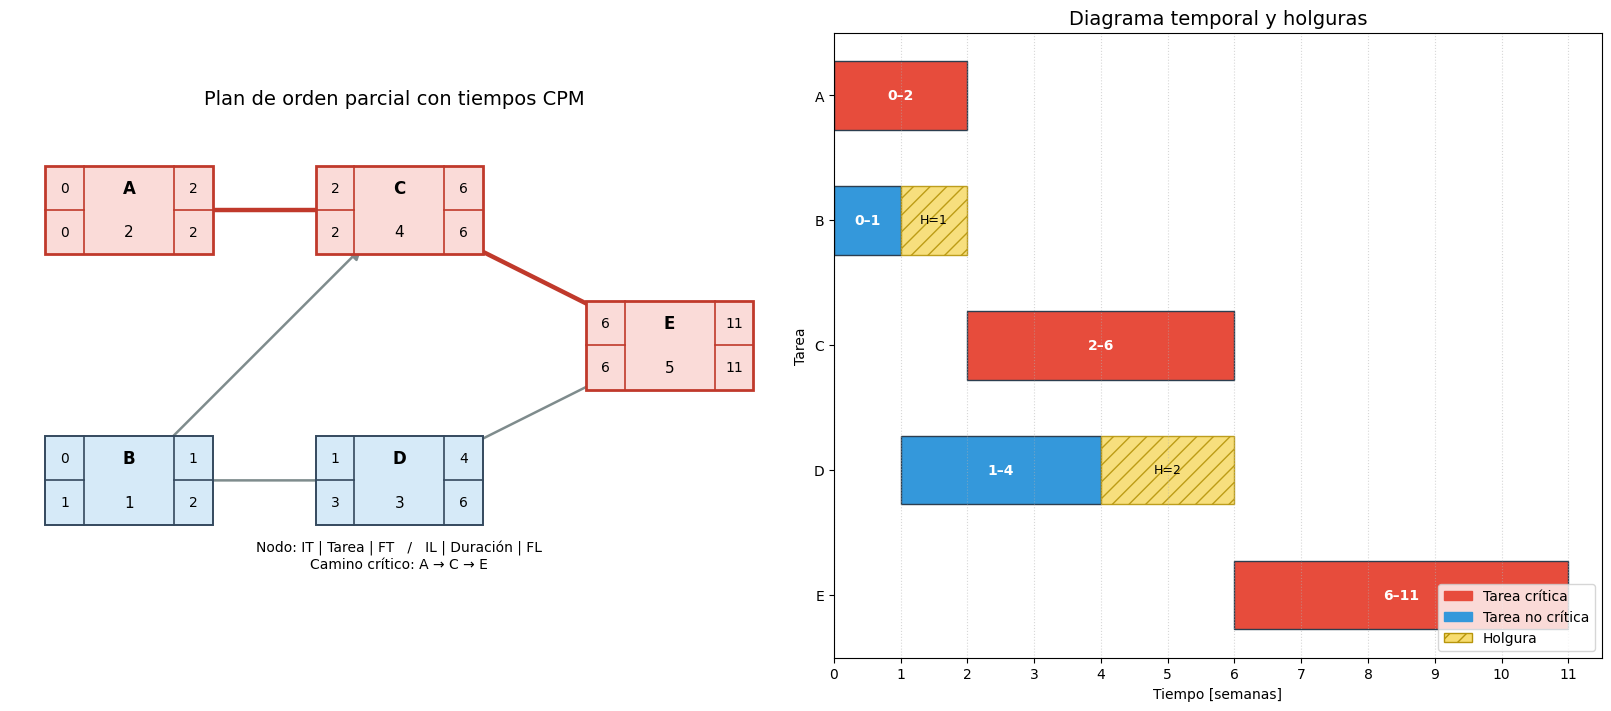

In [4]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Patch, Rectangle


# ============================================================
# 1. DEFINICIÓN DEL PROBLEMA
# ============================================================

duraciones = {
    "A": 2,
    "B": 1,
    "C": 4,
    "D": 3,
    "E": 5,
}

precedencias = [
    ("A", "C"),
    ("B", "C"),
    ("B", "D"),
    ("C", "E"),
    ("D", "E"),
]

grafo = nx.DiGraph()
grafo.add_nodes_from(duraciones)
grafo.add_edges_from(precedencias)

if not nx.is_directed_acyclic_graph(grafo):
    raise ValueError("Las precedencias contienen un ciclo.")

orden = list(nx.topological_sort(grafo))


# ============================================================
# 2. RECORRIDO HACIA ADELANTE: IT Y FT
# ============================================================

inicio_temprano = {}
fin_temprano = {}

for tarea in orden:
    predecesoras = list(
        grafo.predecessors(tarea)
    )

    inicio_temprano[tarea] = max(
        (
            fin_temprano[predecesora]
            for predecesora in predecesoras
        ),
        default=0,
    )

    fin_temprano[tarea] = (
        inicio_temprano[tarea]
        + duraciones[tarea]
    )

duracion_proyecto = max(
    fin_temprano.values()
)


# ============================================================
# 3. RECORRIDO HACIA ATRÁS: FL E IL
# ============================================================

fin_tardio = {}
inicio_tardio = {}

for tarea in reversed(orden):
    sucesoras = list(
        grafo.successors(tarea)
    )

    fin_tardio[tarea] = min(
        (
            inicio_tardio[sucesora]
            for sucesora in sucesoras
        ),
        default=duracion_proyecto,
    )

    inicio_tardio[tarea] = (
        fin_tardio[tarea]
        - duraciones[tarea]
    )


# Holgura total.
holgura = {
    tarea: (
        inicio_tardio[tarea]
        - inicio_temprano[tarea]
    )
    for tarea in grafo.nodes
}

tareas = ["A", "B", "C", "D", "E"]


# ============================================================
# 4. MOSTRAR RESULTADOS
# ============================================================

print(
    f"Duración mínima del proyecto: "
    f"{duracion_proyecto} semanas\n"
)

print(
    f"{'Tarea':<7}"
    f"{'Dur.':>6}"
    f"{'IT':>6}"
    f"{'FT':>6}"
    f"{'IL':>6}"
    f"{'FL':>6}"
    f"{'H':>6}"
)

for tarea in tareas:
    print(
        f"{tarea:<7}"
        f"{duraciones[tarea]:>6}"
        f"{inicio_temprano[tarea]:>6}"
        f"{fin_temprano[tarea]:>6}"
        f"{inicio_tardio[tarea]:>6}"
        f"{fin_tardio[tarea]:>6}"
        f"{holgura[tarea]:>6}"
    )


# ============================================================
# 5. FUNCIÓN PARA DIBUJAR UN NODO CPM
# ============================================================

def dibujar_nodo_cpm(
    ax,
    x,
    y,
    tarea,
    ancho=1.55,
    alto=0.82,
):
    """
    Dibuja un nodo con el formato:

        IT | Tarea    | FT
        IL | Duración | FL
    """

    critica = holgura[tarea] == 0

    color_fondo = (
        "#FADBD8" if critica else "#D6EAF8"
    )

    color_borde = (
        "#C0392B" if critica else "#34495E"
    )

    izquierda = x - ancho / 2
    abajo = y - alto / 2
    ancho_lateral = 0.36

    rectangulo = Rectangle(
        (izquierda, abajo),
        ancho,
        alto,
        facecolor=color_fondo,
        edgecolor=color_borde,
        linewidth=2 if critica else 1.4,
        zorder=3,
    )

    ax.add_patch(rectangulo)

    # Divisiones verticales.
    ax.plot(
        [
            izquierda + ancho_lateral,
            izquierda + ancho_lateral,
        ],
        [abajo, abajo + alto],
        color=color_borde,
        linewidth=1.2,
        zorder=4,
    )

    ax.plot(
        [
            izquierda + ancho - ancho_lateral,
            izquierda + ancho - ancho_lateral,
        ],
        [abajo, abajo + alto],
        color=color_borde,
        linewidth=1.2,
        zorder=4,
    )

    # Divisiones horizontales de los laterales.
    ax.plot(
        [izquierda, izquierda + ancho_lateral],
        [y, y],
        color=color_borde,
        linewidth=1.2,
        zorder=4,
    )

    ax.plot(
        [
            izquierda + ancho - ancho_lateral,
            izquierda + ancho,
        ],
        [y, y],
        color=color_borde,
        linewidth=1.2,
        zorder=4,
    )

    x_izquierdo = (
        izquierda + ancho_lateral / 2
    )

    x_derecho = (
        izquierda
        + ancho
        - ancho_lateral / 2
    )

    desplazamiento_y = alto / 4

    # Columna izquierda: IT e IL.
    ax.text(
        x_izquierdo,
        y + desplazamiento_y,
        inicio_temprano[tarea],
        ha="center",
        va="center",
        fontsize=10,
        zorder=5,
    )

    ax.text(
        x_izquierdo,
        y - desplazamiento_y,
        inicio_tardio[tarea],
        ha="center",
        va="center",
        fontsize=10,
        zorder=5,
    )

    # Columna derecha: FT y FL.
    ax.text(
        x_derecho,
        y + desplazamiento_y,
        fin_temprano[tarea],
        ha="center",
        va="center",
        fontsize=10,
        zorder=5,
    )

    ax.text(
        x_derecho,
        y - desplazamiento_y,
        fin_tardio[tarea],
        ha="center",
        va="center",
        fontsize=10,
        zorder=5,
    )

    # Centro: tarea y duración.
    ax.text(
        x,
        y + desplazamiento_y,
        tarea,
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold",
        zorder=5,
    )

    ax.text(
        x,
        y - desplazamiento_y,
        duraciones[tarea],
        ha="center",
        va="center",
        fontsize=11,
        zorder=5,
    )


# ============================================================
# 6. CREACIÓN DE LA FIGURA
# ============================================================

fig, (ax_grafo, ax_gantt) = plt.subplots(
    1,
    2,
    figsize=(16, 7),
    constrained_layout=True,
)


# ------------------------------------------------------------
# SUBPLOT 1: GRAFO DE PRECEDENCIAS
# ------------------------------------------------------------

posiciones = {
    "A": (0, 1.25),
    "B": (0, -1.25),
    "C": (2.5, 1.25),
    "D": (2.5, -1.25),
    "E": (5.0, 0),
}

# Una arista es crítica si conecta dos tareas críticas
# que se ejecutan consecutivamente.
aristas_criticas = {
    (origen, destino)
    for origen, destino in grafo.edges
    if (
        holgura[origen] == 0
        and holgura[destino] == 0
        and fin_temprano[origen]
        == inicio_temprano[destino]
    )
}

# Flechas de precedencia.
for origen, destino in grafo.edges:
    critica = (
        origen,
        destino,
    ) in aristas_criticas

    flecha = FancyArrowPatch(
        posiciones[origen],
        posiciones[destino],
        arrowstyle="-|>",
        mutation_scale=18,
        linewidth=3.2 if critica else 1.8,
        color=(
            "#C0392B"
            if critica
            else "#7F8C8D"
        ),
        shrinkA=38,
        shrinkB=38,
        zorder=2,
    )

    ax_grafo.add_patch(flecha)

# Nodos con el formato utilizado en el pizarrón.
for tarea, (x, y) in posiciones.items():
    dibujar_nodo_cpm(
        ax_grafo,
        x,
        y,
        tarea,
    )

ax_grafo.set_xlim(-1.1, 6.0)
ax_grafo.set_ylim(-2.15, 2.15)
ax_grafo.set_aspect("equal")

ax_grafo.set_title(
    "Plan de orden parcial con tiempos CPM",
    fontsize=14,
)

ax_grafo.text(
    2.5,
    -1.95,
    "Nodo: IT | Tarea | FT   /   "
    "IL | Duración | FL\n"
    "Camino crítico: A → C → E",
    ha="center",
    va="center",
    fontsize=10,
)

ax_grafo.set_axis_off()


# ------------------------------------------------------------
# SUBPLOT 2: DIAGRAMA TEMPORAL Y HOLGURAS
# ------------------------------------------------------------

for posicion_y, tarea in enumerate(tareas):
    it = inicio_temprano[tarea]
    ft = fin_temprano[tarea]
    h = holgura[tarea]

    color_tarea = (
        "#E74C3C"
        if h == 0
        else "#3498DB"
    )

    # Intervalo temprano de ejecución.
    ax_gantt.barh(
        posicion_y,
        duraciones[tarea],
        left=it,
        height=0.55,
        color=color_tarea,
        edgecolor="#2C3E50",
    )

    ax_gantt.text(
        it + duraciones[tarea] / 2,
        posicion_y,
        f"{it}–{ft}",
        ha="center",
        va="center",
        color="white",
        fontweight="bold",
    )

    # Holgura total.
    if h > 0:
        ax_gantt.barh(
            posicion_y,
            h,
            left=ft,
            height=0.55,
            color="#F7DC6F",
            edgecolor="#B7950B",
            hatch="//",
            alpha=0.9,
        )

        ax_gantt.text(
            ft + h / 2,
            posicion_y,
            f"H={h}",
            ha="center",
            va="center",
            fontsize=9,
        )

ax_gantt.set_yticks(
    range(len(tareas))
)

ax_gantt.set_yticklabels(tareas)
ax_gantt.invert_yaxis()

ax_gantt.set_xlim(
    0,
    duracion_proyecto + 0.5,
)

ax_gantt.set_xticks(
    range(duracion_proyecto + 1)
)

ax_gantt.set_xlabel("Tiempo [semanas]")
ax_gantt.set_ylabel("Tarea")

ax_gantt.set_title(
    "Diagrama temporal y holguras",
    fontsize=14,
)

ax_gantt.grid(
    axis="x",
    linestyle=":",
    alpha=0.5,
)

ax_gantt.legend(
    handles=[
        Patch(
            color="#E74C3C",
            label="Tarea crítica",
        ),
        Patch(
            color="#3498DB",
            label="Tarea no crítica",
        ),
        Patch(
            facecolor="#F7DC6F",
            edgecolor="#B7950B",
            hatch="//",
            label="Holgura",
        ),
    ],
    loc="lower right",
)

plt.show()

Duración mínima del proyecto: 11 semanas

Tarea    Dur.    ES    EF    LS    LF     H
A           2     0     2     0     2     0
B           1     0     1     1     2     1
C           4     2     6     2     6     0
D           3     1     4     3     6     2
E           5     6    11     6    11     0


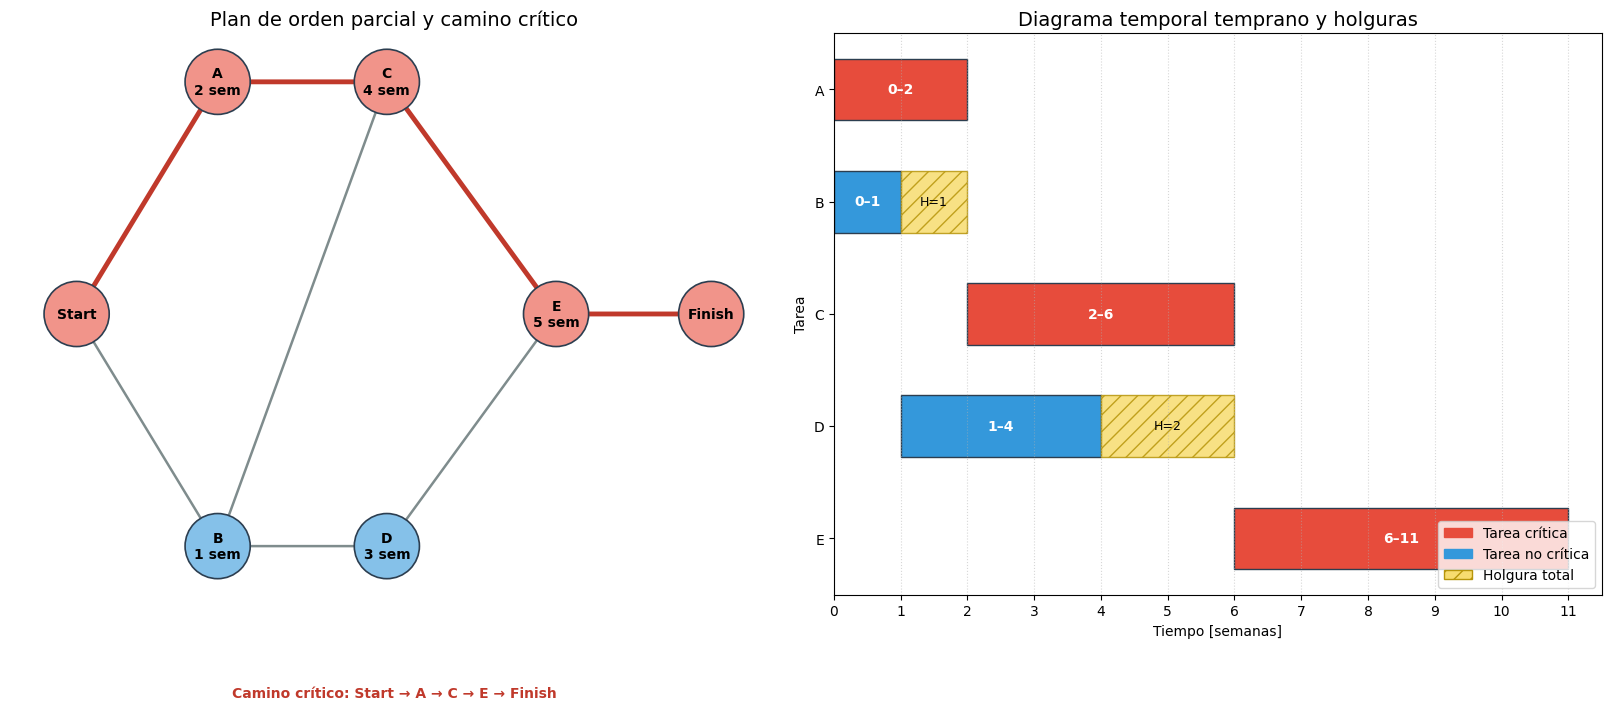

In [5]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


# ============================================================
# 1. DEFINICIÓN DEL PROBLEMA
# ============================================================

duraciones = {
    "Start": 0,
    "A": 2,
    "B": 1,
    "C": 4,
    "D": 3,
    "E": 5,
    "Finish": 0,
}

precedencias = [
    ("Start", "A"),
    ("Start", "B"),
    ("A", "C"),
    ("B", "C"),
    ("B", "D"),
    ("C", "E"),
    ("D", "E"),
    ("E", "Finish"),
]

grafo = nx.DiGraph()
grafo.add_nodes_from(duraciones)
grafo.add_edges_from(precedencias)

# Un plan de precedencias válido no puede contener ciclos.
if not nx.is_directed_acyclic_graph(grafo):
    raise ValueError("Las precedencias contienen un ciclo.")

orden = list(nx.topological_sort(grafo))


# ============================================================
# 2. FORWARD PASS: ES Y EF
# ============================================================

inicio_temprano = {}
fin_temprano = {}

for tarea in orden:
    predecesoras = list(grafo.predecessors(tarea))

    inicio_temprano[tarea] = max(
        (fin_temprano[p] for p in predecesoras),
        default=0,
    )

    fin_temprano[tarea] = (
        inicio_temprano[tarea] + duraciones[tarea]
    )

duracion_proyecto = fin_temprano["Finish"]


# ============================================================
# 3. BACKWARD PASS: LF Y LS
# ============================================================

fin_tardio = {}
inicio_tardio = {}

for tarea in reversed(orden):
    sucesoras = list(grafo.successors(tarea))

    fin_tardio[tarea] = min(
        (inicio_tardio[s] for s in sucesoras),
        default=duracion_proyecto,
    )

    inicio_tardio[tarea] = (
        fin_tardio[tarea] - duraciones[tarea]
    )


# Holgura total de cada tarea.
holgura = {
    tarea: inicio_tardio[tarea] - inicio_temprano[tarea]
    for tarea in grafo.nodes
}

tareas_reales = ["A", "B", "C", "D", "E"]


# ============================================================
# 4. MOSTRAR LOS RESULTADOS NUMÉRICOS
# ============================================================

print(
    f"Duración mínima del proyecto: "
    f"{duracion_proyecto} semanas\n"
)

print(
    f"{'Tarea':<7}{'Dur.':>6}{'ES':>6}{'EF':>6}"
    f"{'LS':>6}{'LF':>6}{'H':>6}"
)

for tarea in tareas_reales:
    print(
        f"{tarea:<7}"
        f"{duraciones[tarea]:>6}"
        f"{inicio_temprano[tarea]:>6}"
        f"{fin_temprano[tarea]:>6}"
        f"{inicio_tardio[tarea]:>6}"
        f"{fin_tardio[tarea]:>6}"
        f"{holgura[tarea]:>6}"
    )


# ============================================================
# 5. CREACIÓN DE LA FIGURA
# ============================================================

fig, (ax_grafo, ax_gantt) = plt.subplots(
    1,
    2,
    figsize=(16, 7),
    constrained_layout=True,
)


# ------------------------------------------------------------
# SUBPLOT 1: PLAN DE ORDEN PARCIAL
# ------------------------------------------------------------

posiciones = {
    "Start": (0, 0),
    "A": (1, 1),
    "B": (1, -1),
    "C": (2.2, 1),
    "D": (2.2, -1),
    "E": (3.4, 0),
    "Finish": (4.5, 0),
}

# Una tarea es crítica cuando su holgura es cero.
nodos_criticos = {
    nodo
    for nodo in grafo.nodes
    if holgura[nodo] == 0
}

# Una arista pertenece al camino crítico si conecta dos nodos
# críticos y el segundo comienza cuando termina el primero.
aristas_criticas = {
    (origen, destino)
    for origen, destino in grafo.edges
    if (
        origen in nodos_criticos
        and destino in nodos_criticos
        and fin_temprano[origen]
        == inicio_temprano[destino]
    )
}

colores_nodos = [
    "#F1948A"
    if nodo in nodos_criticos
    else "#85C1E9"
    for nodo in grafo.nodes
]

colores_aristas = [
    "#C0392B"
    if arista in aristas_criticas
    else "#7F8C8D"
    for arista in grafo.edges
]

anchos_aristas = [
    3.5
    if arista in aristas_criticas
    else 1.8
    for arista in grafo.edges
]

etiquetas = {
    nodo: (
        nodo
        if nodo in {"Start", "Finish"}
        else f"{nodo}\n{duraciones[nodo]} sem"
    )
    for nodo in grafo.nodes
}

nx.draw_networkx_nodes(
    grafo,
    pos=posiciones,
    node_color=colores_nodos,
    node_size=2200,
    edgecolors="#2C3E50",
    linewidths=1.2,
    ax=ax_grafo,
)

nx.draw_networkx_labels(
    grafo,
    pos=posiciones,
    labels=etiquetas,
    font_size=10,
    font_weight="bold",
    ax=ax_grafo,
)

nx.draw_networkx_edges(
    grafo,
    pos=posiciones,
    edge_color=colores_aristas,
    width=anchos_aristas,
    arrows=True,
    arrowsize=22,
    ax=ax_grafo,
)

ax_grafo.set_title(
    "Plan de orden parcial y camino crítico",
    fontsize=14,
)

ax_grafo.text(
    2.25,
    -1.65,
    "Camino crítico: Start → A → C → E → Finish",
    color="#C0392B",
    ha="center",
    fontsize=10,
    fontweight="bold",
)

ax_grafo.set_axis_off()


# ------------------------------------------------------------
# SUBPLOT 2: DIAGRAMA DE GANTT CON HOLGURAS
# ------------------------------------------------------------

for posicion_y, tarea in enumerate(tareas_reales):
    es = inicio_temprano[tarea]
    ef = fin_temprano[tarea]
    h = holgura[tarea]

    color_tarea = (
        "#E74C3C" if h == 0 else "#3498DB"
    )

    # Barra de ejecución según el calendario temprano.
    ax_gantt.barh(
        posicion_y,
        duraciones[tarea],
        left=es,
        height=0.55,
        color=color_tarea,
        edgecolor="#2C3E50",
    )

    ax_gantt.text(
        es + duraciones[tarea] / 2,
        posicion_y,
        f"{es}–{ef}",
        ha="center",
        va="center",
        color="white",
        fontweight="bold",
    )

    # Extensión correspondiente a la holgura total.
    if h > 0:
        ax_gantt.barh(
            posicion_y,
            h,
            left=ef,
            height=0.55,
            color="#F7DC6F",
            edgecolor="#B7950B",
            hatch="//",
            alpha=0.85,
        )

        ax_gantt.text(
            ef + h / 2,
            posicion_y,
            f"H={h}",
            ha="center",
            va="center",
            fontsize=9,
        )

ax_gantt.set_yticks(range(len(tareas_reales)))
ax_gantt.set_yticklabels(tareas_reales)
ax_gantt.invert_yaxis()

ax_gantt.set_xlim(0, duracion_proyecto + 0.5)
ax_gantt.set_xticks(
    range(duracion_proyecto + 1)
)

ax_gantt.set_xlabel("Tiempo [semanas]")
ax_gantt.set_ylabel("Tarea")

ax_gantt.set_title(
    "Diagrama temporal temprano y holguras",
    fontsize=14,
)

ax_gantt.grid(
    axis="x",
    linestyle=":",
    alpha=0.5,
)

ax_gantt.legend(
    handles=[
        Patch(
            color="#E74C3C",
            label="Tarea crítica",
        ),
        Patch(
            color="#3498DB",
            label="Tarea no crítica",
        ),
        Patch(
            facecolor="#F7DC6F",
            edgecolor="#B7950B",
            hatch="//",
            label="Holgura total",
        ),
    ],
    loc="lower right",
)

plt.show()

## Ejercicios de Implementación

> Recuerde adjuntar en la presentación el prompt inicial que ha utilizado para cada ejercicio de implementación y si considera que le dio la información completa para resolver el ejercicio o qué cambios adicionales tuvo que pedir de manera iterativa.

6. Suponga que tiene un robot de oficina capaz de moverse y tomar y depositar objetos. El robot solo puede tener un objeto a la vez, pero puede conseguir una *caja* en la que depositar varios objetos. Suponga que programa al robot para *ir a la tienda* a comprarle un *café* y en el camino de vuelta tome una *carta* del *buzón* de la oficina para para que se la traiga junto con el café. Describa en lenguaje STRIPS:

        6.1 El dominio del robot (nombre, predicados y acciones que puede hacer el robot).

        6.2 El problema que se quiere resolver (estado inicial, estado objetivo y objetos del mundo representados).

        6.3 Introduzca el código desarrollado en los puntos anteriores en el [planificador online](http://lcas.lincoln.ac.uk/fast-downward/) y obtenga el plan de acción que tomará el robot para cumplir lo solicitado.


# Bibliografía

[Russell, S. & Norvig, P. (2004) _Inteligencia Artificial: Un Enfoque Moderno_. Pearson Educación S.A. (2a Ed.) Madrid, España](https://www.academia.edu/8241613/Inteligencia_Aritificial_Un_Enfoque_Moderno_2da_Edici%C3%B3n_Stuart_J_Russell_y_Peter_Norvig)

[Poole, D. & Mackworth, A. (2023) _Artificial Intelligence: Foundations of Computational Agents_. Cambridge University Press (3a Ed.) Vancouver, Canada](https://artint.info/3e/html/ArtInt3e.html)